In [1]:
import os
import joblib
import pandas as pd

BASE_DIR = os.path.dirname(os.getcwd())  # notebook is one level inside project root
models_dir = os.path.join(BASE_DIR, "models")

# Load the trained models
model_24h = joblib.load(os.path.join(models_dir, "model_24h.pkl"))
model_48h = joblib.load(os.path.join(models_dir, "model_48h.pkl"))
model_72h = joblib.load(os.path.join(models_dir, "model_72h.pkl"))

print("Models loaded.")

Models loaded.


In [2]:
data_path = os.path.join(BASE_DIR, "data", "engineered_features.csv")
df = pd.read_csv(data_path)
df["time"] = pd.to_datetime(df["time"])

SPLIT_DATE = "2026-02-01"
test = df[df["time"] >= SPLIT_DATE].copy()
test = test.dropna()

feature_cols = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "precipitation",
    "surface_pressure", "wind_speed_10m", "wind_direction_10m",
    "pm2_5", "pm10", "nitrogen_dioxide", "ozone", "sulphur_dioxide", "carbon_monoxide",
    "hour", "month", "day_of_week",
    "aqi_lag_1h", "aqi_lag_3h", "aqi_lag_6h", "aqi_lag_24h",
    "aqi_change_rate_1h", "aqi_change_rate_24h"
]

X_test = test[feature_cols]

print(f"X_test shape: {X_test.shape}")

X_test shape: (4272, 22)


In [3]:
train = df[df["time"] < SPLIT_DATE].copy()
train = train.dropna()

X_train = train[feature_cols]

print(f"X_train shape: {X_train.shape}")


X_train shape: (18264, 22)


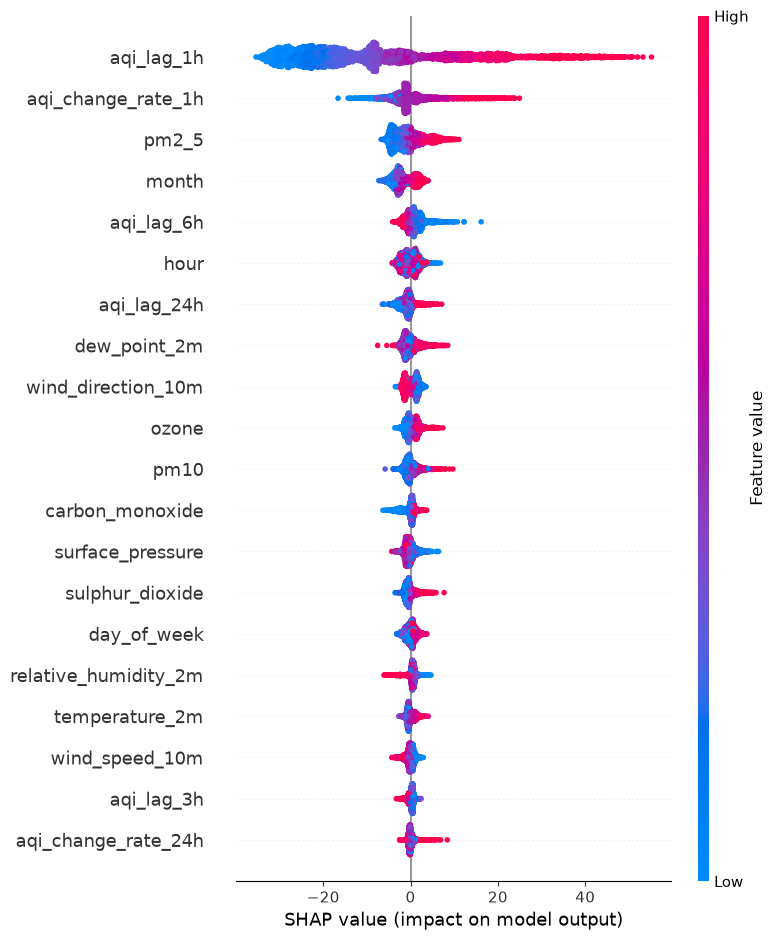

In [4]:
import shap
import matplotlib.pyplot as plt

explainer_24h = shap.TreeExplainer(model_24h)
shap_values_24h = explainer_24h.shap_values(X_test)

shap.summary_plot(shap_values_24h, X_test, show=False)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "notebooks", "shap_summary_24h.png"), dpi=150)
plt.show()

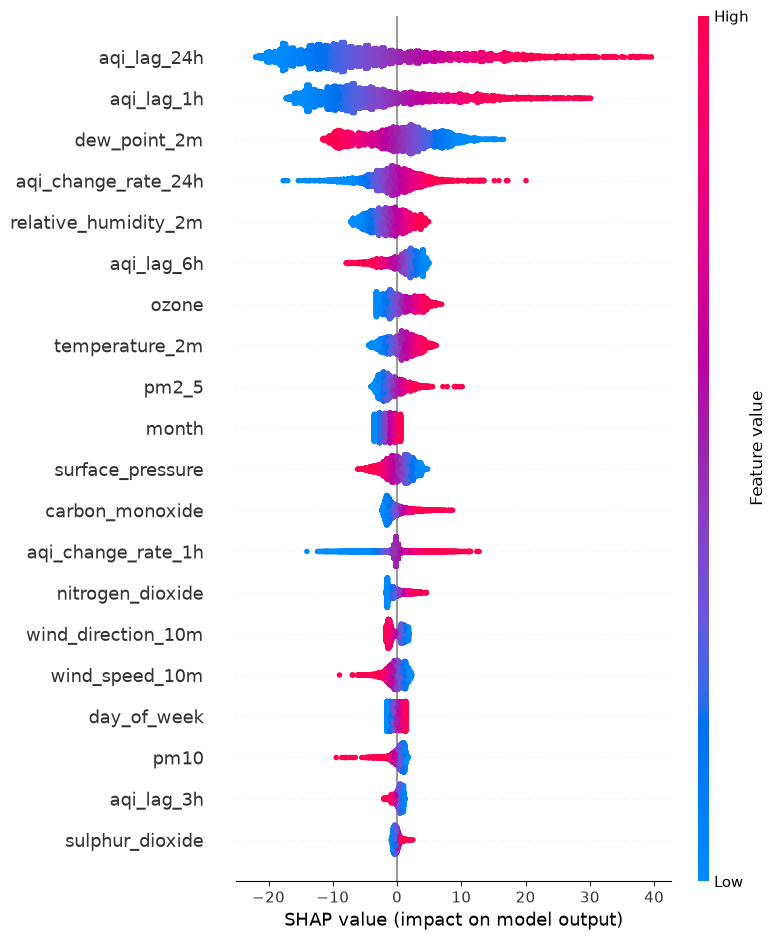

In [5]:
# 48h model
explainer_48h = shap.LinearExplainer(model_48h, X_train)
shap_values_48h = explainer_48h.shap_values(X_test)

shap.summary_plot(shap_values_48h, X_test, show=False)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "notebooks", "shap_summary_48h.png"), dpi=150)
plt.show()

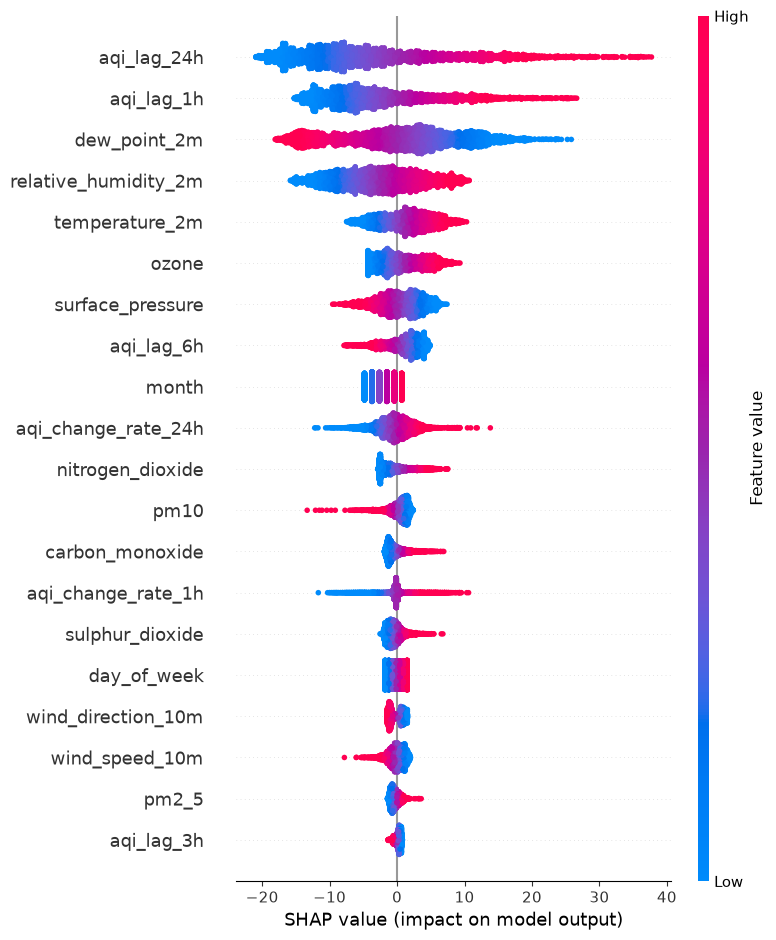

In [6]:
# 72h model
explainer_72h = shap.LinearExplainer(model_72h, X_train)
shap_values_72h = explainer_72h.shap_values(X_test)

shap.summary_plot(shap_values_72h, X_test, show=False)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "notebooks", "shap_summary_72h.png"), dpi=150)
plt.show()